# [LAB-02] 비지도학습 > 군집분석 > KMeans ㅣ Base Model 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


## 📚 몇 개의 그룹으로 나눌 것인가

### 당신은 게임 회사 한울소프트의 데이터 분석가입니다.

이용자 100명의 하루 평균 이용시간과 게임 레벨을 `game_usage` 데이터로 모아 두었고, 다음 달 이벤트를 이용자 그룹별로 다르게 준비하려고 합니다.

팀장은 "일단 4개 그룹으로 나눠 보라"고 했지만, 마케팅팀은 3개면 충분하다고 하고 기획팀은 5개, 6개까지 쪼개 보자고 합니다. 모두 나름의 근거가 있어 보입니다.

그룹 개수를 바꿔 가며 실제로 나눠 본 뒤, 어떤 개수가 이번 이벤트에 가장 알맞은지 당신이 판단하고 근거를 대야 합니다.

> 랜덤시드는 `helpers`에 정의된 `RANDOM_STATE`(3217)로 고정한 채 분석합니다. 고정하지 않으면 실행할 때마다 그룹 번호도 인원도 달라져서, 그룹 개수끼리 비교하는 일 자체가 되지 않습니다.

### 💻 코드 작성

#### 데이터 가져오기

In [2]:
origin = load_data('game_usage')
origin.head()

📚 게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


#### 이용자 분포 확인

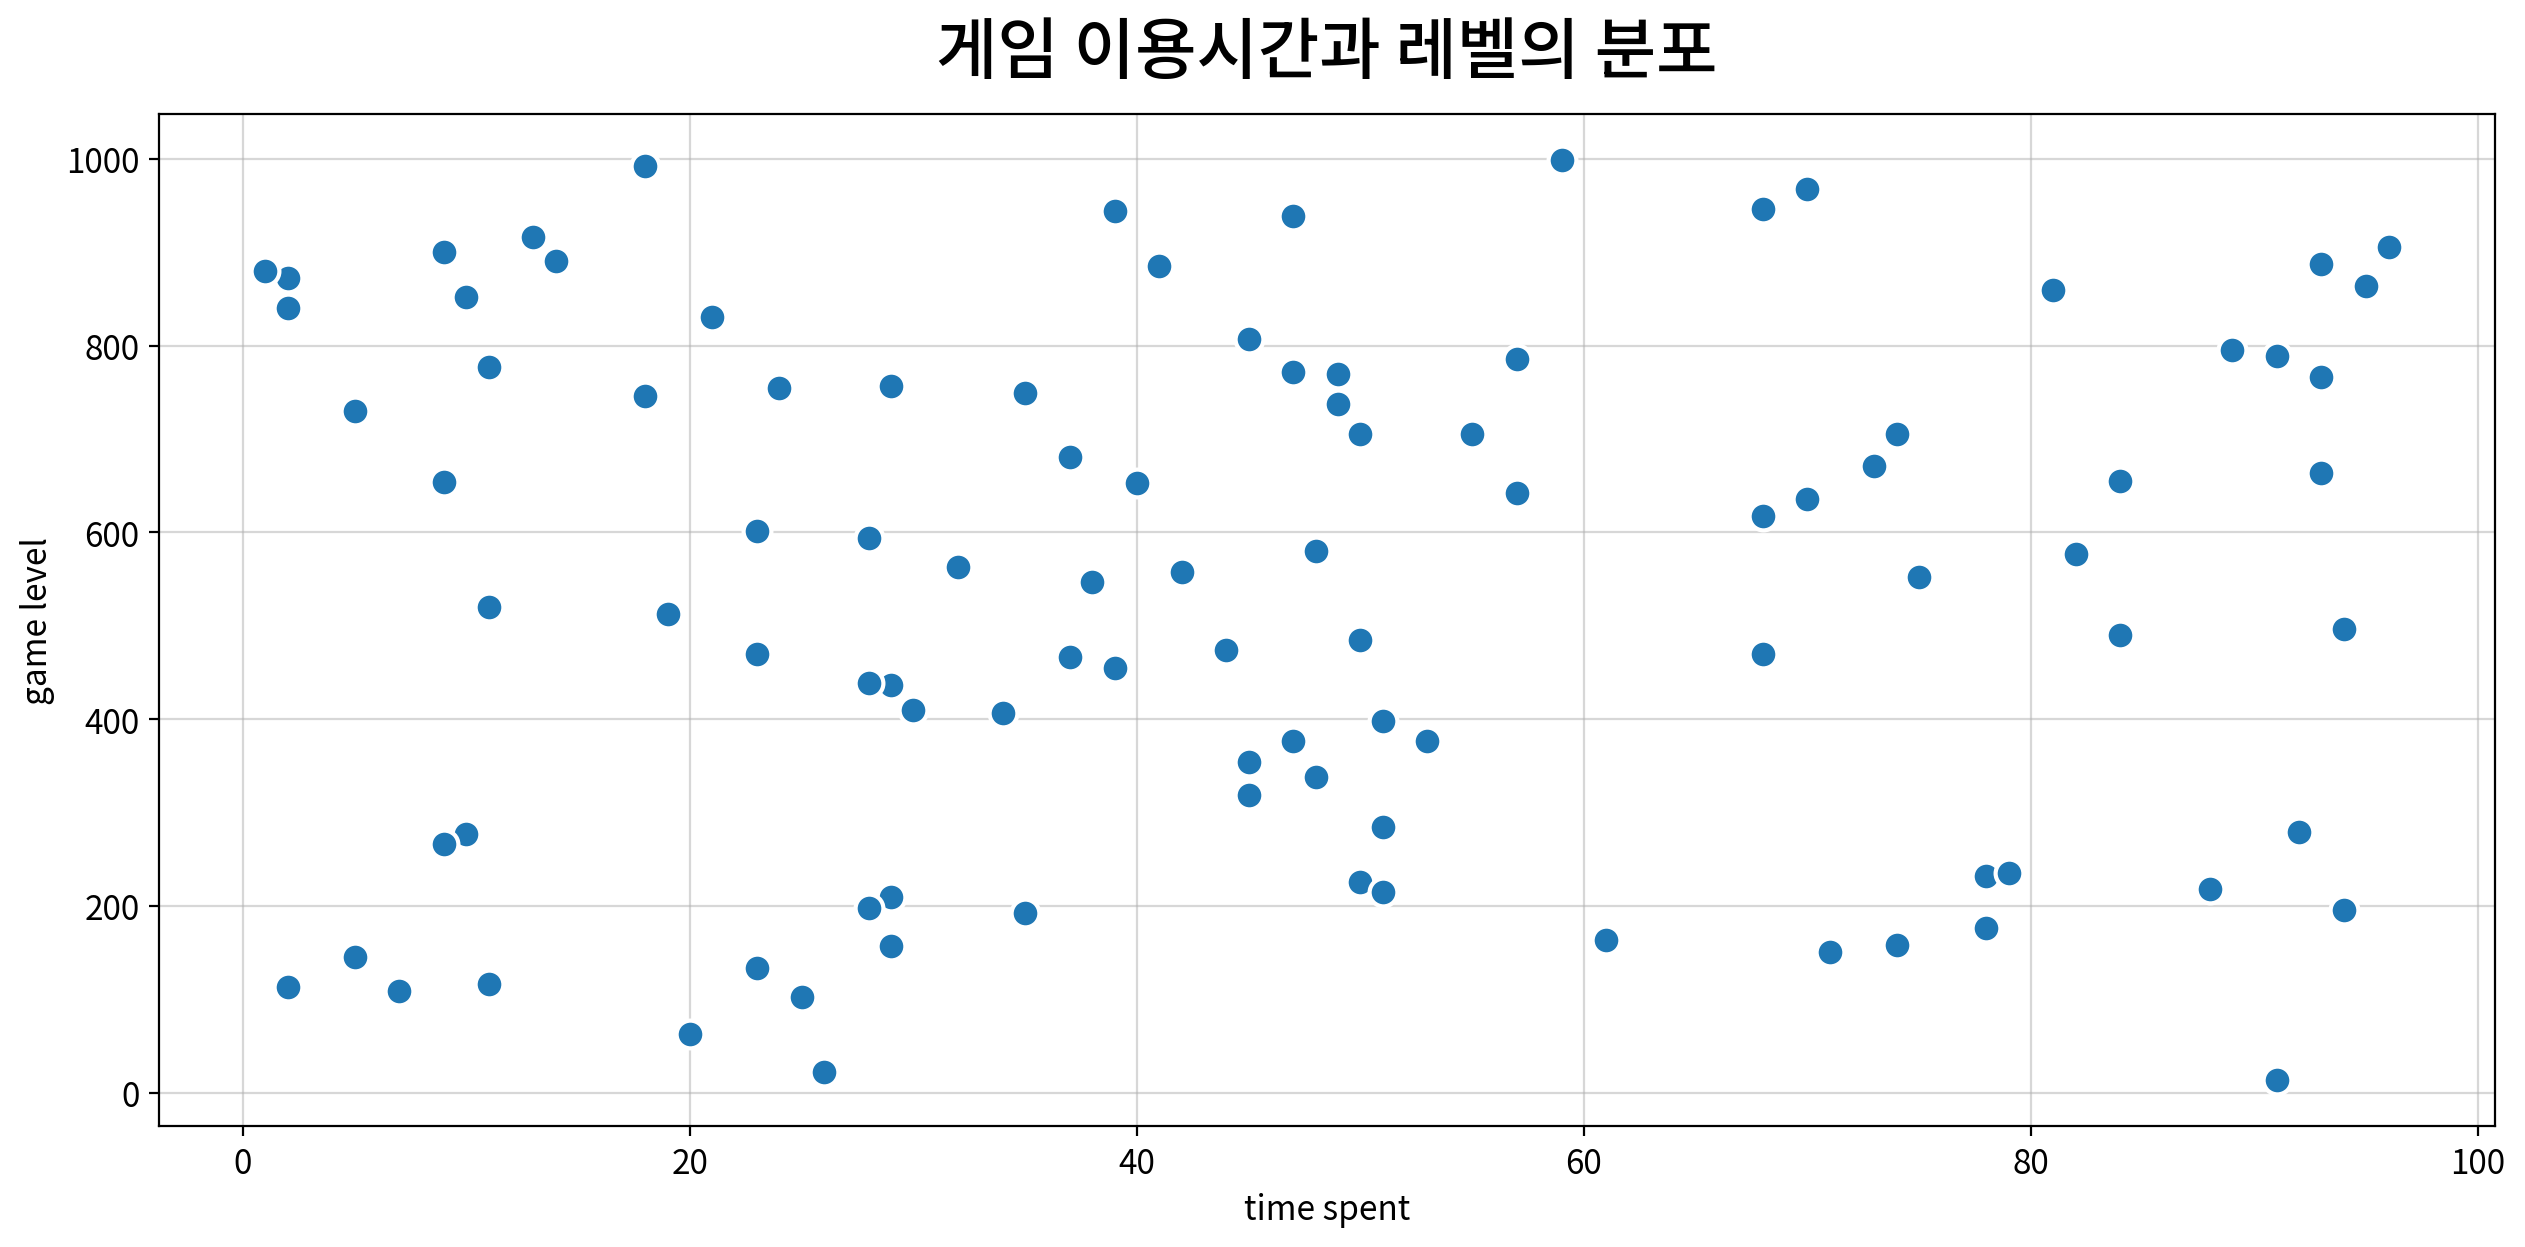

In [3]:
my_plot.scatterplot(data=origin, x='time spent', y='game level',
                    title='게임 이용시간과 레벨의 분포')

#### 그룹 개수를 2~6개로 바꿔 가며 나누기

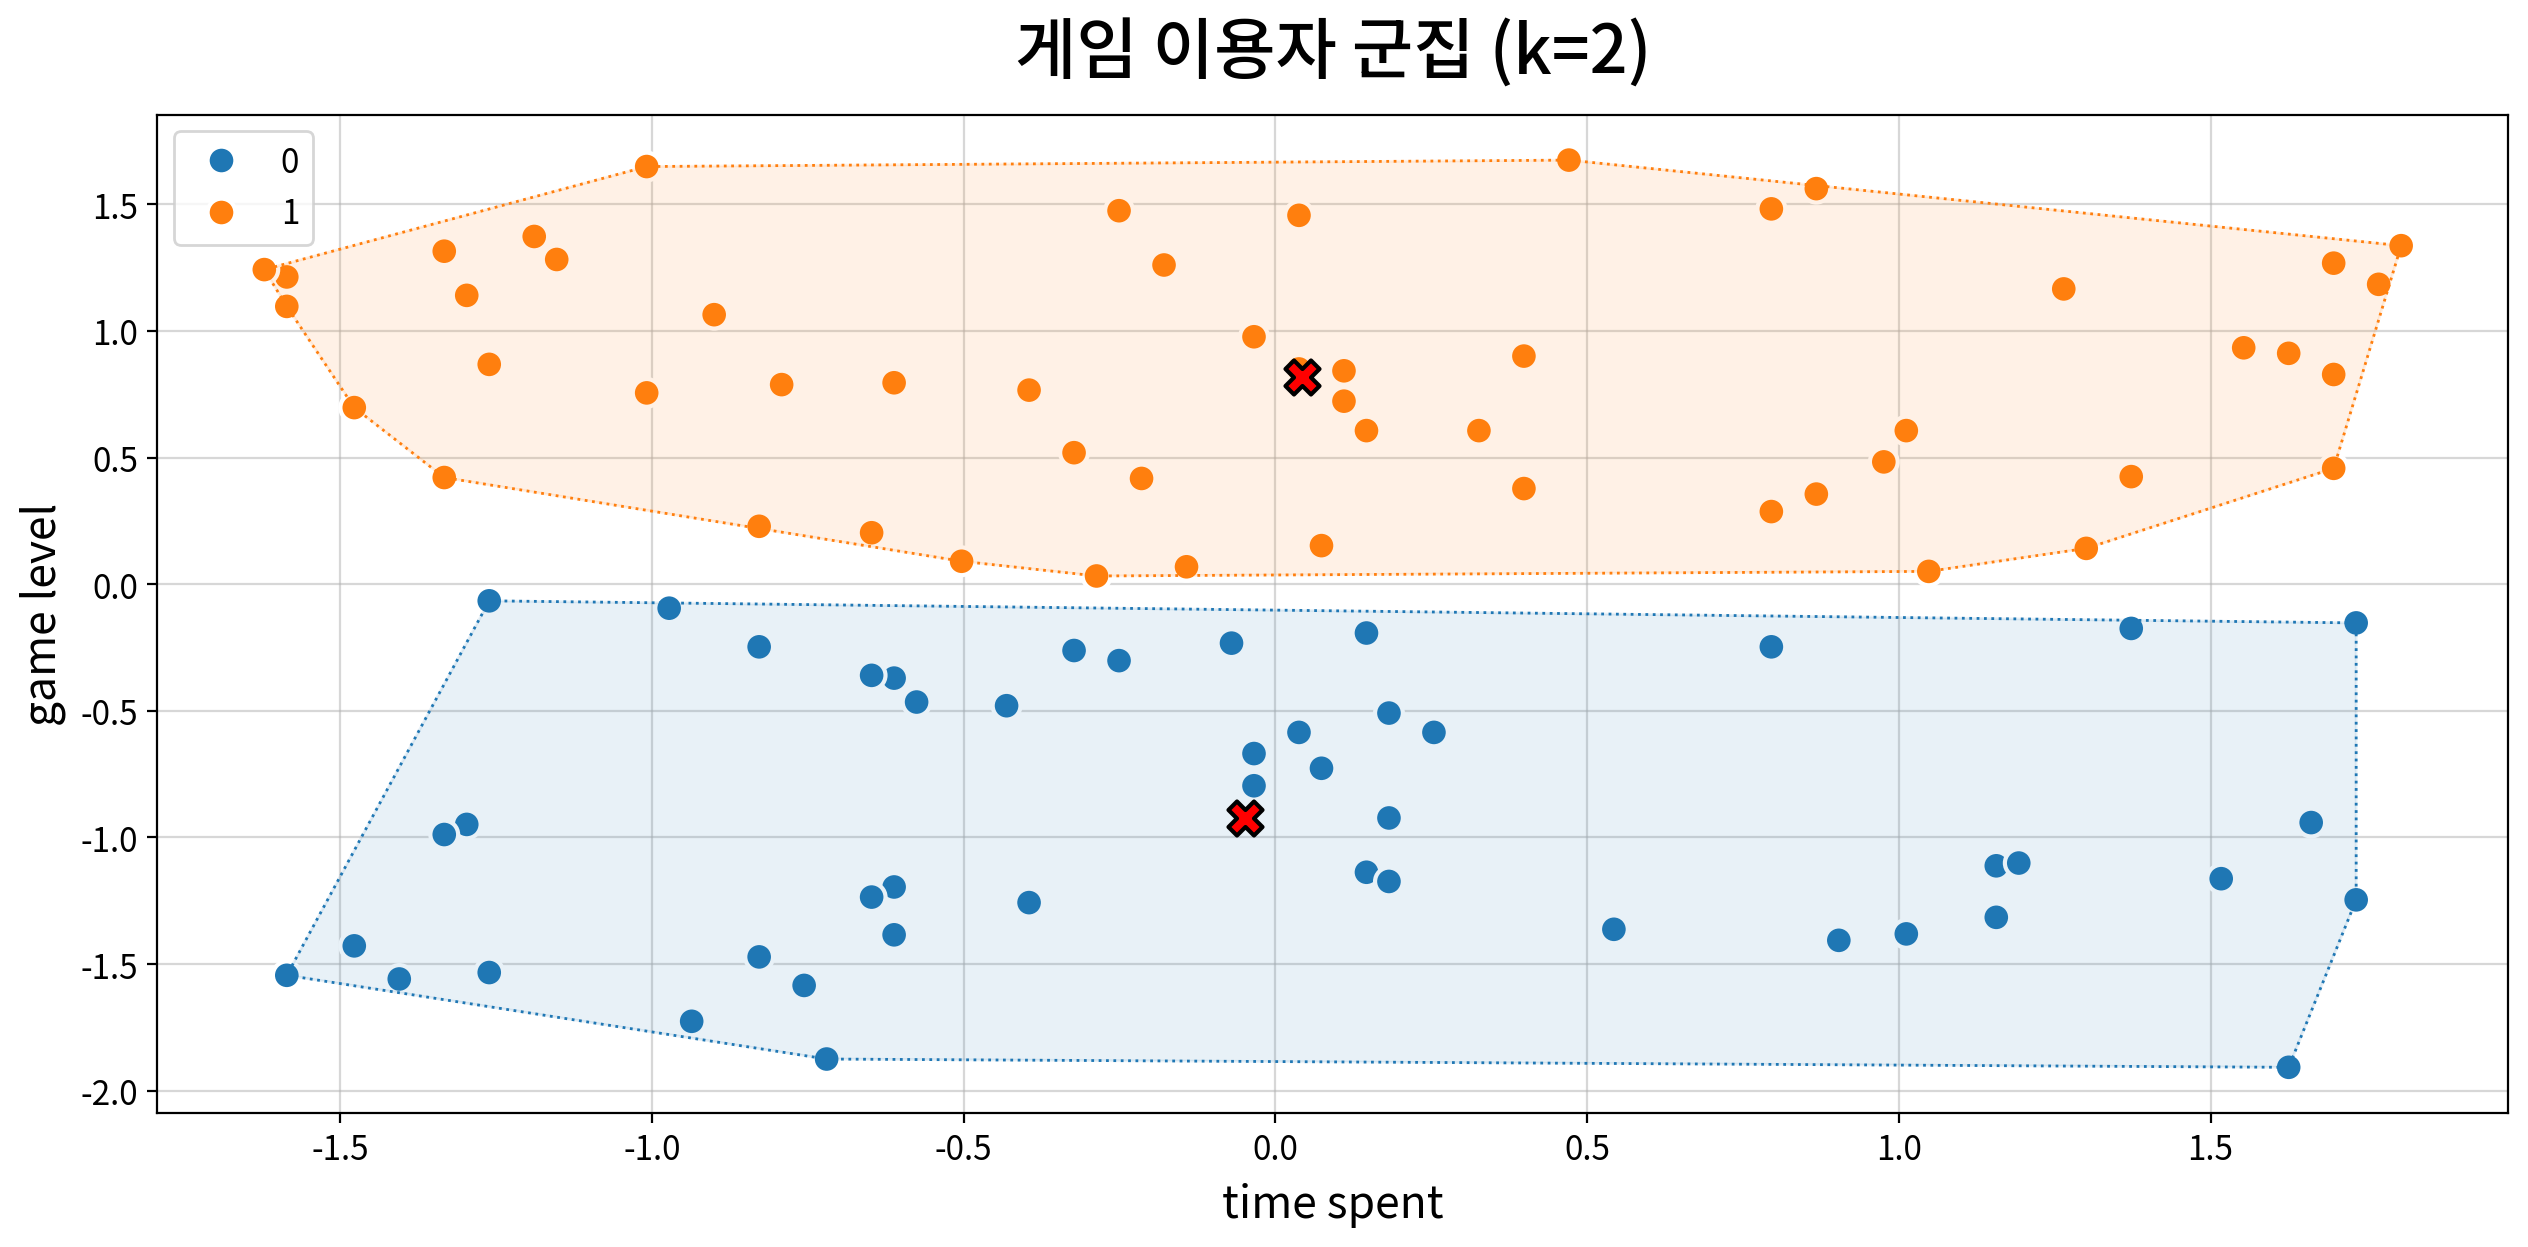

[k=2] 그룹별 인원: [53, 47] / 가장 작은 그룹: 47명


,time spent,game level,인원
0,-0.050,-0.920,47
1,0.040,0.820,53


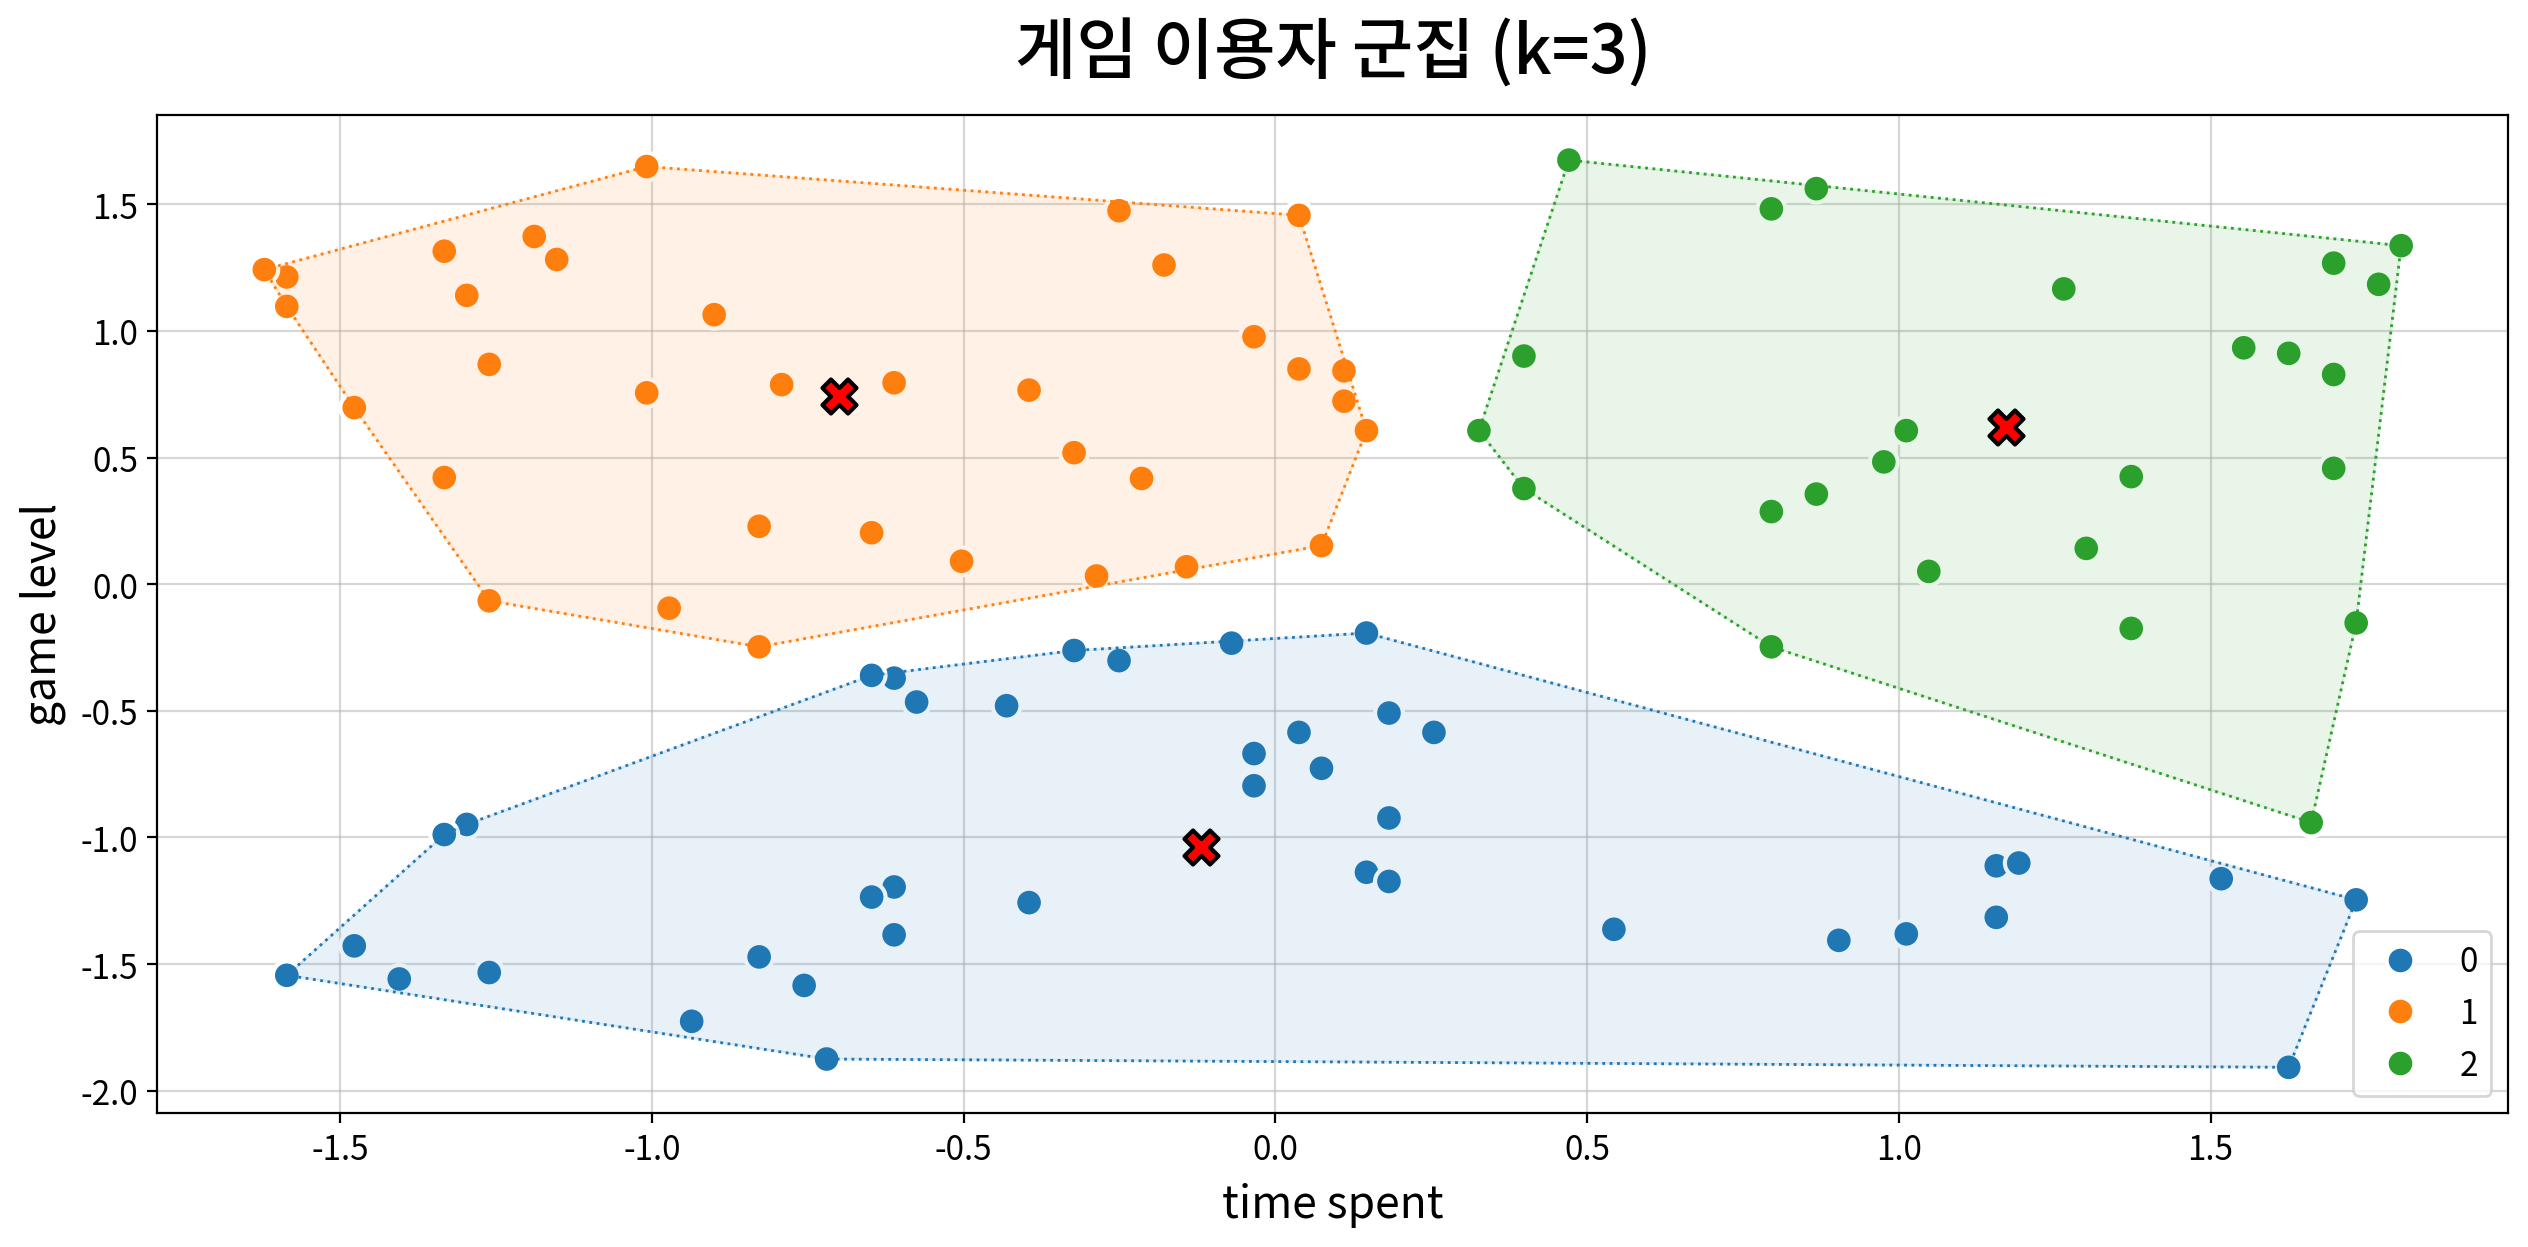

[k=3] 그룹별 인원: [40, 35, 25] / 가장 작은 그룹: 25명


,time spent,game level,인원
0,-0.120,-1.040,40
1,-0.700,0.740,35
2,1.170,0.620,25


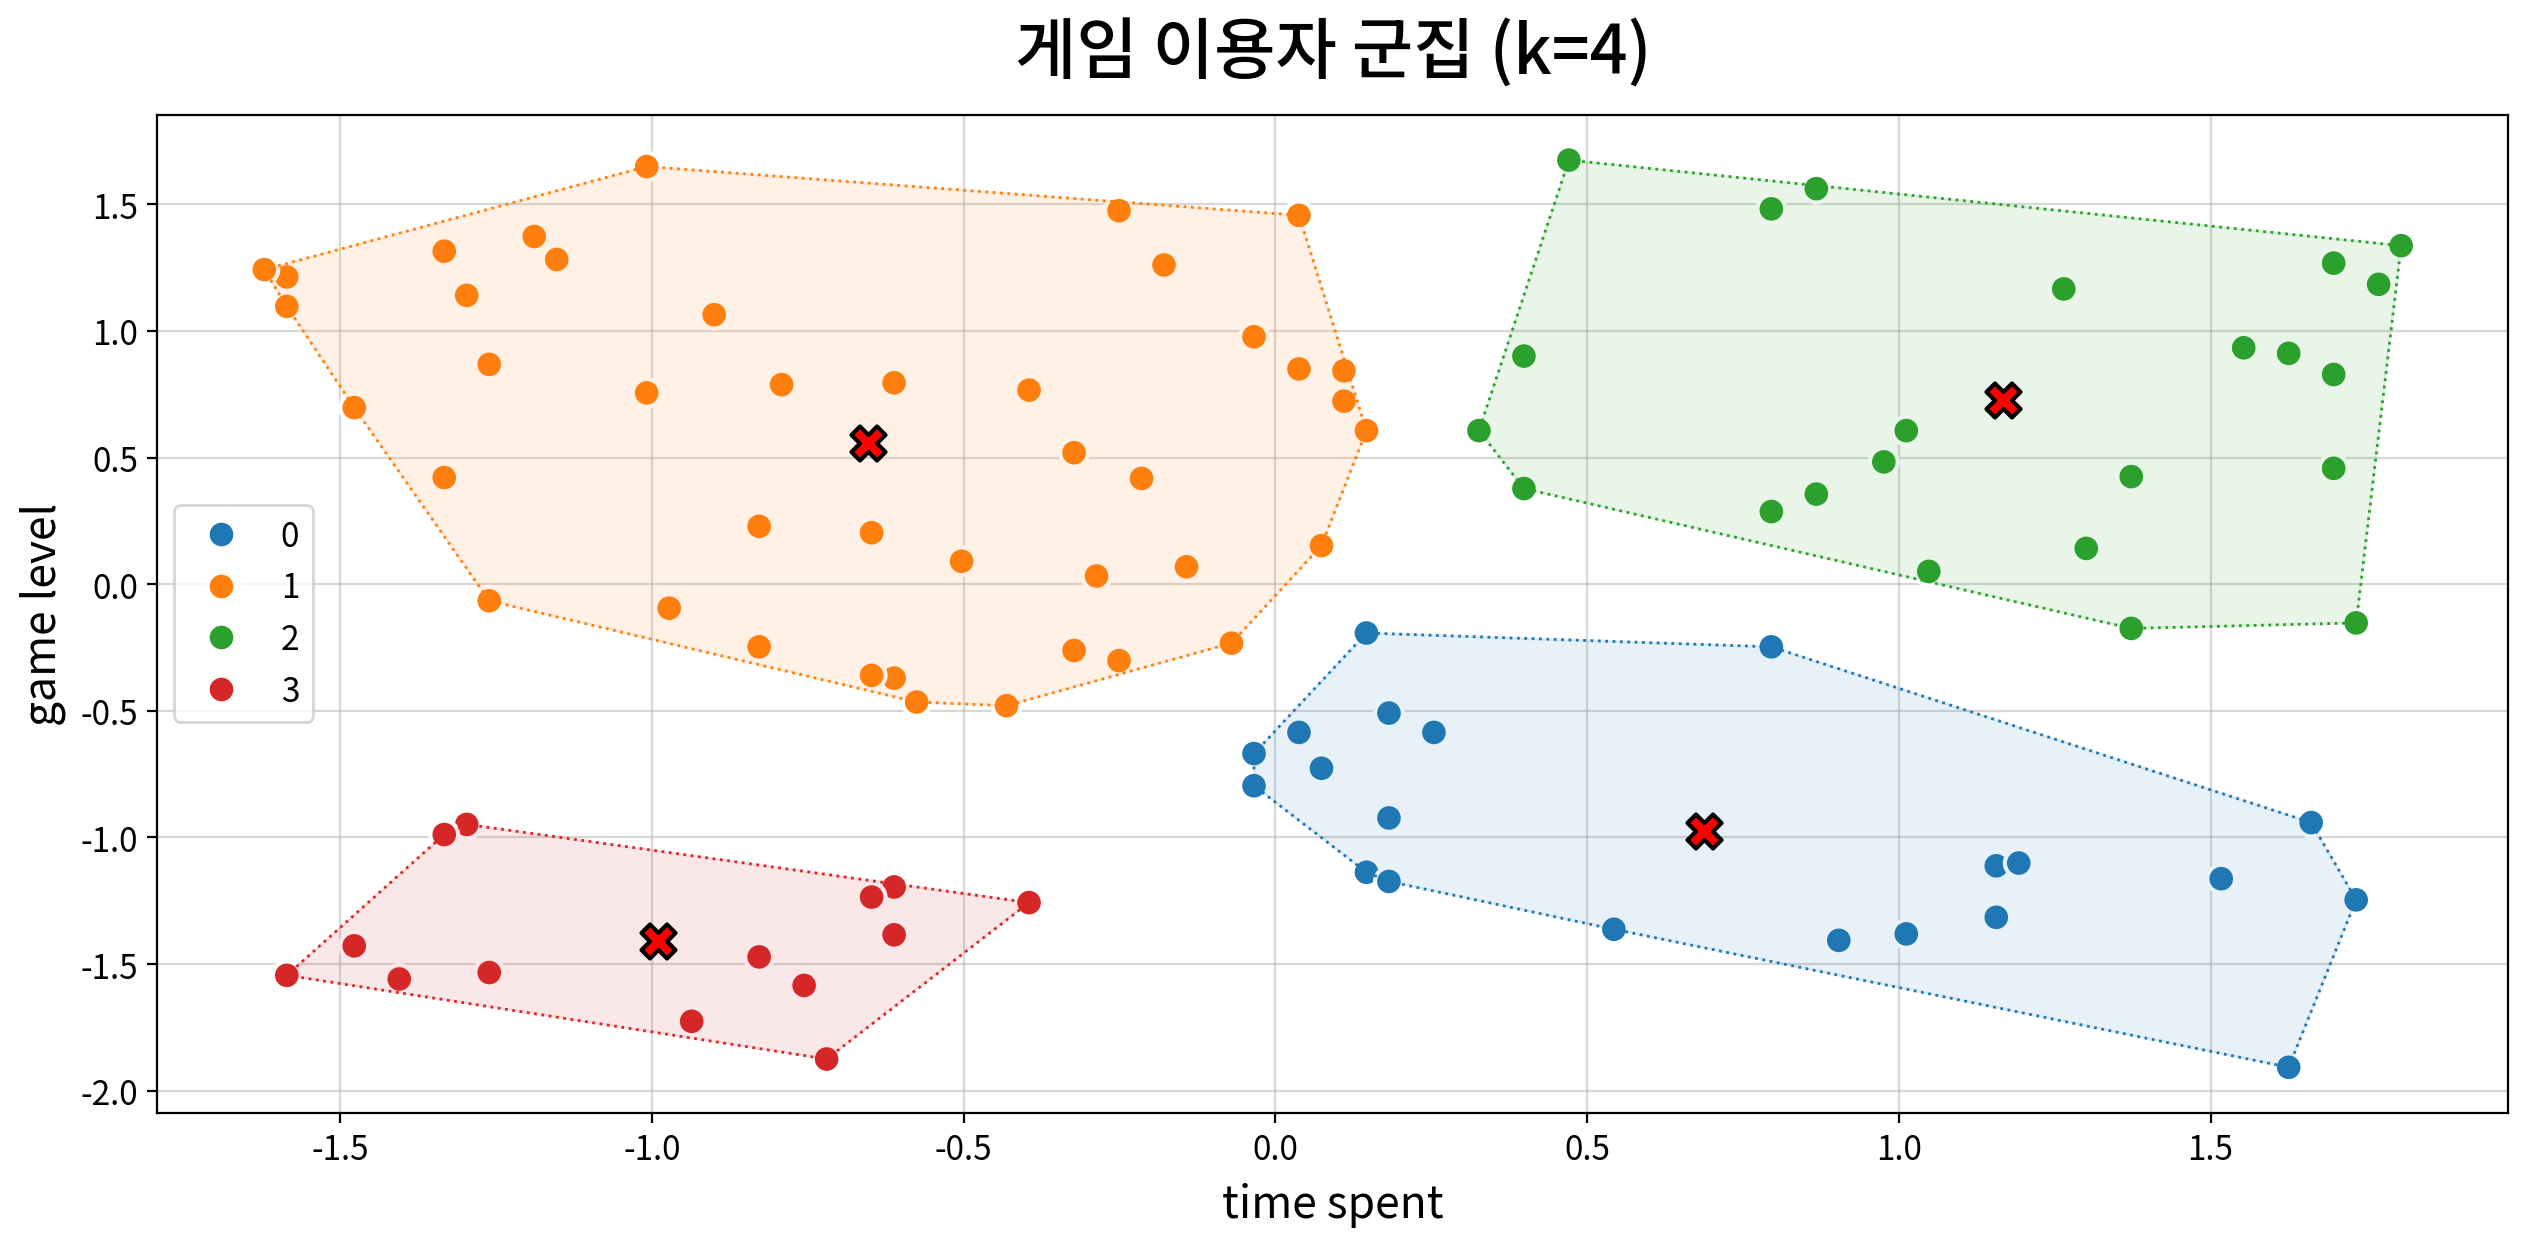

[k=4] 그룹별 인원: [42, 23, 21, 14] / 가장 작은 그룹: 14명


,time spent,game level,인원
0,0.690,-0.980,21
1,-0.650,0.560,42
2,1.170,0.730,23
3,-0.990,-1.410,14


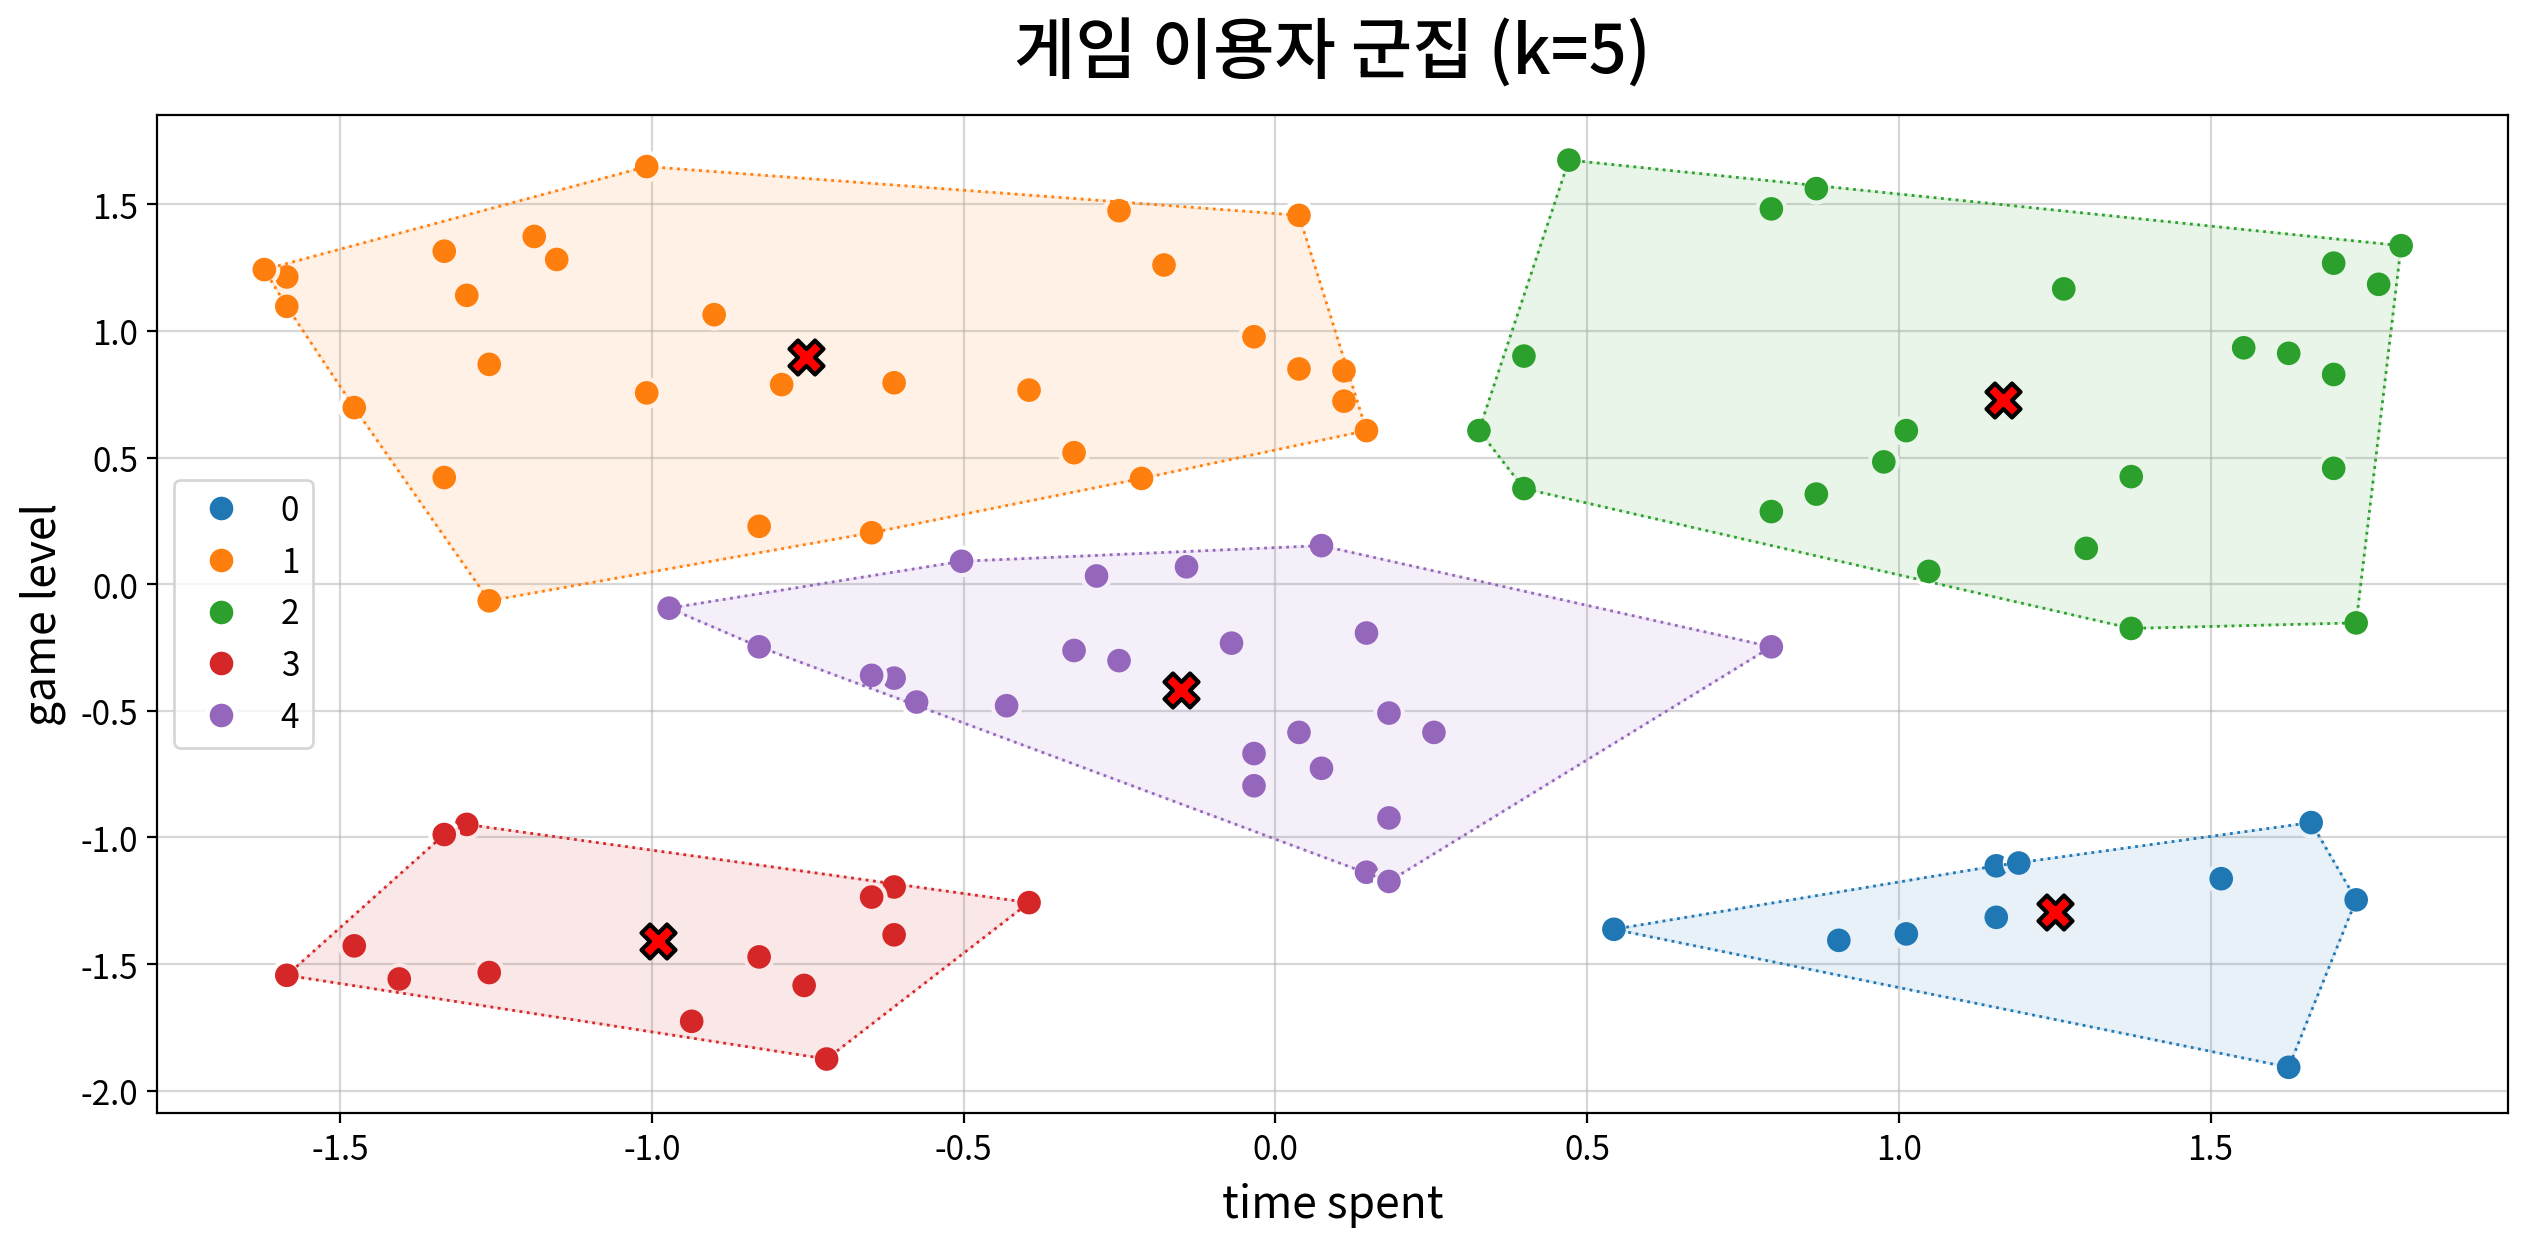

[k=5] 그룹별 인원: [29, 24, 23, 14, 10] / 가장 작은 그룹: 10명


,time spent,game level,인원
0,1.250,-1.290,10
1,-0.750,0.900,29
2,1.170,0.730,23
3,-0.990,-1.410,14
4,-0.150,-0.420,24


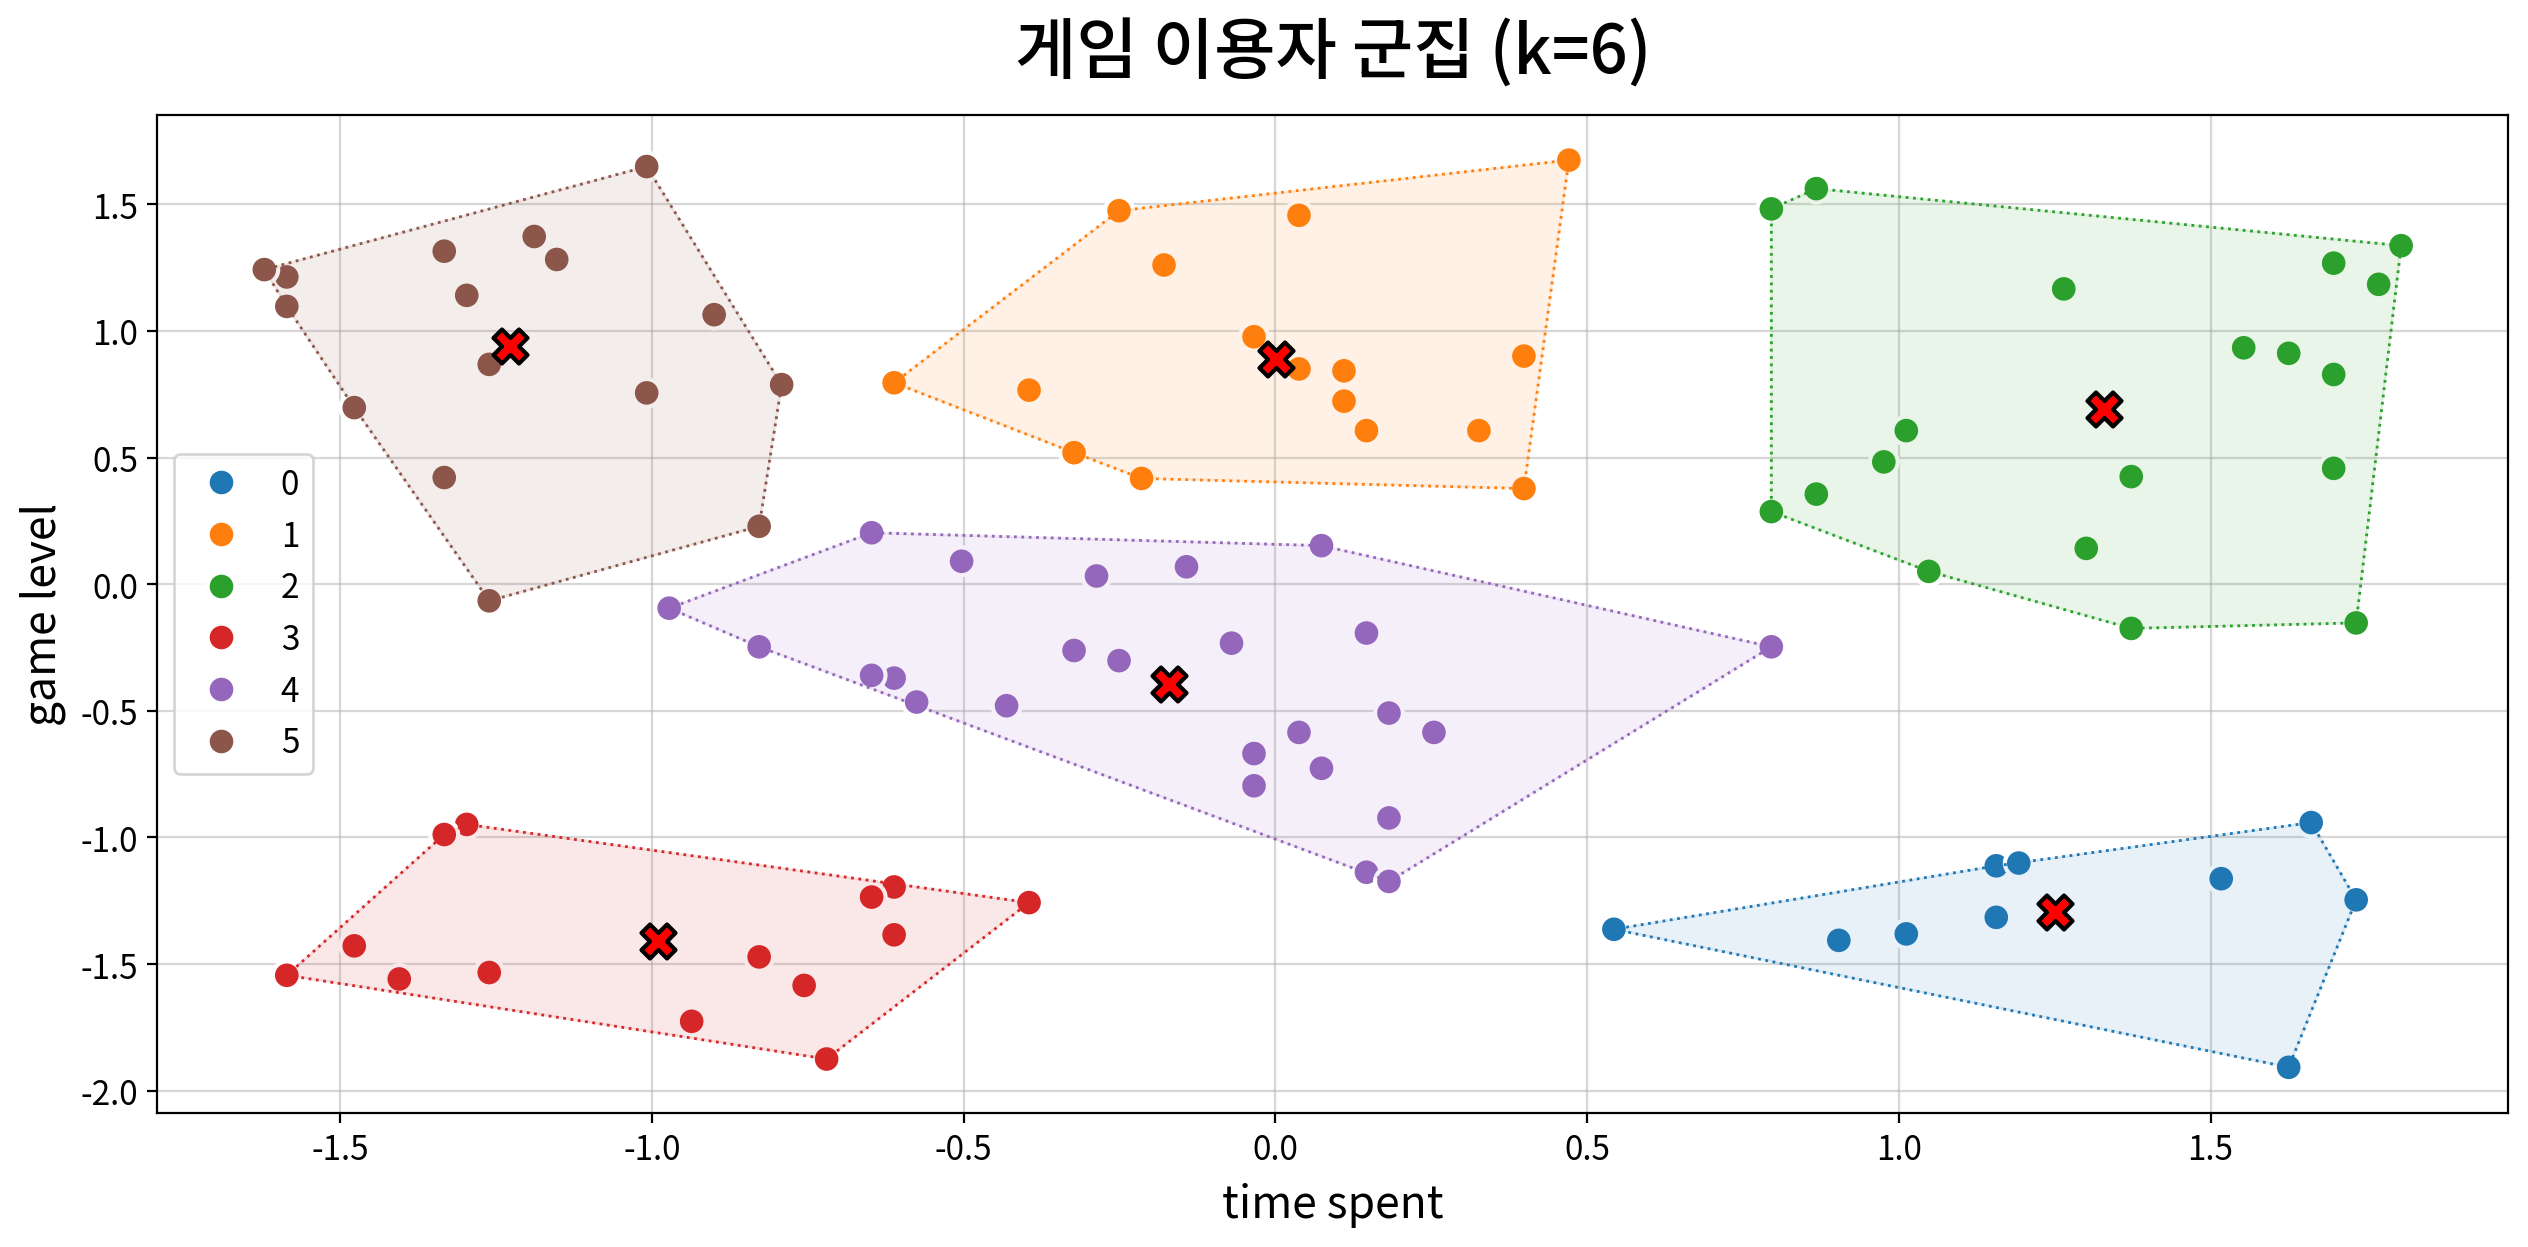

[k=6] 그룹별 인원: [25, 19, 16, 16, 14, 10] / 가장 작은 그룹: 10명


,time spent,game level,인원
0,1.250,-1.290,10
1,0.000,0.890,16
2,1.330,0.690,19
3,-0.990,-1.410,14
4,-0.170,-0.390,25
5,-1.230,0.940,16


In [4]:
for k in range(2, 7):
    estimator, df, center_df = my_cluster.kmeans(origin, k=k, verbose=False, title=f'게임 이용자 군집 (k={k})')

    center_df['인원'] = df['그룹번호'].value_counts().sort_index()
    sizes = sorted(center_df['인원'], reverse=True)

    print(f'[k={k}] 그룹별 인원: {sizes} / 가장 작은 그룹: {min(sizes)}명')
    display(center_df.round(2))

#### 그룹 개수별 인원 요약

In [5]:
summary = []

for k in range(2, 7):
    estimator, df, center_df = my_cluster.kmeans(origin, k=k, plot=False, verbose=False,
                                                 random_state=RANDOM_STATE)
    sizes = sorted(df['그룹번호'].value_counts(), reverse=True)
    summary.append({'그룹 개수': k, '그룹별 인원': sizes, '가장 작은 그룹': min(sizes)})

DataFrame(summary)

,그룹 개수,그룹별 인원,가장 작은 그룹
0,2,"[53, 47]",47
1,3,"[40, 35, 25]",25
2,4,"[42, 23, 21, 14]",14
3,5,"[29, 24, 23, 14, 10]",10
4,6,"[25, 19, 16, 16, 14, 10]",10


### 문제 풀이

#### 1. 가장 단순하게 이용자를 2개 그룹으로만 나눠 봤습니다. 두 그룹의 중심점을 비교해 보면, 두 그룹을 실질적으로 갈라놓은 것은 두 변수 중 어느 쪽인가요?

- **정답**: `game level`
- **복습 개념**: 중심점 좌표로 그룹의 성격을 읽는 연습입니다. 중심점 좌표는 전체 평균을 0으로 놓고 본 값이므로, 그룹 사이에 크게 벌어지는 좌표가 곧 그룹을 가르는 기준입니다.
- **풀이 접근**: 이용자를 2개 그룹으로 나눈 뒤 두 그룹의 중심점 좌표를 나란히 놓고, 이용시간 쪽과 레벨 쪽 중 어느 좌표가 더 크게 벌어지는지 비교합니다.
- **근거(계산 결과)**: 두 중심점은 (-0.05, -0.92)와 (0.04, 0.82)입니다. 이용시간 좌표는 -0.05와 0.04로 0.09밖에 차이 나지 않는 반면, 레벨 좌표는 -0.92와 0.82로 1.74나 벌어집니다. 즉 **`game level`** 이 높은 무리와 낮은 무리로 갈라놓은 것입니다.
- **함께 생각해 볼 점**: 그룹을 2개만 만들면 알고리즘은 가장 크게 벌어지는 방향 하나만 잡아냅니다. "오래 하는데 레벨은 낮은" 이용자처럼 두 변수를 함께 봐야 보이는 유형은 이 단계에서는 드러나지 않습니다. 개수를 늘려 가며 무엇이 새로 보이는지 살펴보세요.

#### 2. 팀장의 말대로 이용자를 4개 그룹으로 나눴습니다. 이때 인원이 가장 많은 그룹에는 몇 명이 속하나요? (명)

- **정답**: `42`
- **복습 개념**: 군집화 결과를 그림이 아니라 숫자로 확인하는 단계입니다. 각 데이터가 몇 번 그룹인지 예측한 뒤 그룹별로 개수를 세면 그룹의 크기를 알 수 있습니다.
- **풀이 접근**: 4개 그룹으로 나눈 뒤 예측된 그룹 번호를 데이터에 컬럼으로 붙이고, 그룹 번호별 빈도를 셉니다.
- **근거(계산 결과)**: 그룹별 인원은 **42명**, 23명, 21명, 14명입니다. 가장 큰 42명 그룹의 중심점은 (-0.65, 0.56)으로, 이용시간은 평균보다 적은데 레벨은 평균보다 높은 이용자들입니다.
- **헷갈리기 쉬운 점**: 그룹 번호(0, 1, 2, 3)는 크기순도, 중요도순도 아닙니다. 실행할 때 정해지는 이름표일 뿐이라 랜덤시드를 바꾸면 같은 무리에 다른 번호가 붙습니다. 번호 자체에 의미를 두지 마세요.

#### 3. 그룹 개수를 2개부터 6개까지 하나씩 늘려 가며 나눠 보면, 어느 순간부터 인원이 15명도 되지 않는 작은 그룹이 생겨납니다. 그런 그룹이 처음 나타나는 것은 몇 개로 나눴을 때인가요?

- **정답**: `4`
- **복습 개념**: 그룹 개수를 늘리면 무슨 일이 벌어지는지 관찰하는 문항입니다. 개수를 늘릴수록 큰 덩어리가 잘게 쪼개지면서 인원이 적은 그룹이 생깁니다.
- **풀이 접근**: 그룹 개수를 2, 3, 4, 5, 6으로 바꿔 가며 각각 나눈 뒤, 매번 그룹별 인원을 세어 가장 작은 그룹의 인원을 기록해 비교합니다.
- **근거(계산 결과)**: 가장 작은 그룹의 인원은 2개일 때 47명, 3개일 때 25명, **4개일 때 14명**, 5개일 때 10명, 6개일 때 10명입니다. 15명 미만이 처음 나오는 것은 **4개**로 나눴을 때입니다.
- **함께 생각해 볼 점**: 잘게 쪼갤수록 각 그룹은 더 촘촘해지지만, 대신 인원이 너무 적어 따로 관리할 가치가 없는 그룹이 생깁니다. 어느 쪽이 더 손해인지는 데이터가 알려주지 않습니다.

#### 4. 5개 그룹으로 나눈 결과에는 중심점의 두 좌표가 모두 0에 가까워(절댓값 0.5 미만) 성격을 한마디로 설명하기 어려운 그룹이 하나 있습니다. 이 그룹에는 몇 명이 속하나요? (명)

- **정답**: `24`
- **복습 개념**: 중심점 좌표는 전체 평균을 0으로 놓고 본 값입니다. 중심점이 0 근처라는 것은 "이 그룹은 이용시간도 레벨도 평균 수준이라 특징이 뚜렷하지 않다"는 뜻입니다.
- **풀이 접근**: 5개 그룹으로 나눈 뒤 중심점 표와 그룹별 인원을 함께 놓고, 두 좌표가 모두 0에 가까운 행을 찾아 그 그룹의 인원을 읽습니다.
- **근거(계산 결과)**: 5개 그룹의 중심점은 (1.25, -1.29), (-0.75, 0.90), (1.17, 0.73), (-0.99, -1.41), 그리고 **(-0.15, -0.42)** 입니다. 마지막 그룹만 두 좌표가 모두 0.5 미만이고 인원은 **24명**입니다. 나머지 넷은 "오래 하는데 레벨은 낮다", "짧게 하는데 레벨이 높다"처럼 한 문장으로 설명되지만 이 그룹만 그렇지 않습니다.
- **실무 포인트**: 이런 그룹을 만나면 "이벤트를 뭘 줘야 하지?"라는 질문에 답할 수가 없습니다. 개수를 늘려 놓고도 이렇게 설명이 안 되는 그룹이 생긴다면, 그 개수가 이 문제에 맞지 않는다는 신호로 읽으세요.

#### 5. 운영팀에서 "이벤트 하나를 돌리려면 대상이 최소 15명은 되어야 한다"는 조건을 걸었습니다. 2개부터 6개까지 중, 모든 그룹이 이 조건을 만족하는 가장 큰 그룹 개수는 몇 개인가요?

- **정답**: `3`
- **복습 개념**: 군집 개수를 고르는 기준이 데이터 안에만 있지 않다는 것을 확인하는 마지막 단계입니다. 같은 데이터라도 무엇에 쓸 것이냐에 따라 알맞은 개수가 달라집니다.
- **풀이 접근**: 그룹 개수별로 가장 작은 그룹의 인원을 모아 놓은 요약표에서, 그 값이 15 이상인 행 중 그룹 개수가 가장 큰 것을 고릅니다.
- **근거(계산 결과)**: 가장 작은 그룹의 인원은 2개일 때 47명, 3개일 때 25명, 4개일 때 14명, 5개일 때 10명, 6개일 때 10명입니다. 15명 이상을 지키는 것은 2개와 3개뿐이고, 그중 큰 쪽은 **3개**입니다. 팀장이 말한 4개는 14명짜리 그룹 때문에 조건에 걸립니다.
- **결론**: 데이터는 2개로 나눠 달라면 2개로, 6개로 나눠 달라면 6개로 군말 없이 나눠 줍니다. 어느 쪽도 틀린 답이 아니고, 어느 쪽도 데이터가 골라 준 정답이 아닙니다. 이번에 3개라고 답할 수 있었던 것은 "한 그룹에 15명 이상"이라는 운영 조건이 있었기 때문일 뿐입니다. 조건이 "이벤트를 6종 준비했다"였다면 답은 6개가 됐을 것이고, 조건이 없었다면 답도 없습니다. 그래서 당신이 팀장에게 보고할 말은 "4개가 틀렸습니다"가 아니라 **"무엇에 쓸 그룹인지 먼저 정해 주세요"** 입니다. 군집분석에서 개수를 정하는 것은 데이터가 아니라 목적입니다.